# Data Source Fetchers Exploration
In this notebook, we explore the data fetched by the new `src.data` module, which has been expanded to include real historical Corporate Credit indices, SOFR curves, and Global Sovereigns.


In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import datetime
import matplotlib.pyplot as plt

from src.data.fred import FredFetcher  # noqa: E402
from src.data.corporate import CorporateFetcher  # noqa: E402
from src.data.sofr import SofrFetcher  # noqa: E402
from src.data.global_sovereign import GlobalSovereignFetcher  # noqa: E402

import logging

logging.basicConfig(level=logging.INFO)

## 1. Fetching US Treasuries and SOFR
Let's see how our baseline risk-free curves look.


In [2]:
date = datetime.date(2024, 6, 15)

try:
    fred_fetcher = FredFetcher()
    fred_data = fred_fetcher.fetch_yield_curve(date)
    print("FRED Treasury Data:\n", fred_data, "\n")
except Exception as e:
    print("FRED Treasury Failed:", e)

try:
    sofr_fetcher = SofrFetcher()
    sofr_data = sofr_fetcher.fetch_yield_curve(date)
    print("SOFR Short-Term Data:\n", sofr_data, "\n")
except Exception as e:
    print("SOFR Failed:", e)

INFO:src.data.sofr:Fetching SOFR curve from FRED for date 2024-06-15


FRED Treasury Data:
 {0.25: 0.055099999999999996, 1.0: 0.0507, 2.0: 0.0467, 5.0: 0.042199999999999994, 10.0: 0.042, 30.0: 0.0434} 



SOFR Short-Term Data:
 {0.0027397260273972603: 0.053099999999999994, 0.0821917808219178: 0.0533303, 0.2465753424657534: 0.053526199999999996, 0.4931506849315068: 0.0538874} 



## 2. Fetching Real Corporate Credit Data
We can pull actual historical ICE BofA corporate yields (Broad Market, BBB, High Yield).


In [3]:
try:
    # Broad Market (Proxy 7.0 years)
    corp_broad = CorporateFetcher(rating="ALL", proxy_maturity=7.0)
    corp_data = corp_broad.fetch_yield_curve(date)

    # BBB Rated (Proxy 7.0 years)
    corp_bbb = CorporateFetcher(rating="BBB", proxy_maturity=7.0)
    bbb_data = corp_bbb.fetch_yield_curve(date)

    # High Yield (Proxy 5.0 years as HY typically has shorter duration)
    corp_hy = CorporateFetcher(rating="HY", proxy_maturity=5.0)
    hy_data = corp_hy.fetch_yield_curve(date)

    print("Corporate (Broad):", corp_data)
    print("Corporate (BBB):", bbb_data)
    print("Corporate (High Yield):", hy_data)
except Exception as e:
    print("Corporate Fetch Failed:", e)

INFO:src.data.corporate:Fetching Corporate ALL index yield from FRED for date 2024-06-15


INFO:src.data.corporate:Fetching Corporate BBB index yield from FRED for date 2024-06-15


INFO:src.data.corporate:Fetching Corporate HY index yield from FRED for date 2024-06-15


Corporate (Broad): {7.0: 0.0536}
Corporate (BBB): {7.0: 0.0555}
Corporate (High Yield): {5.0: 0.0761}


## 3. Global Sovereign Yields (10-Year)
Let's look at 10-year yields from the Euro Area, UK, and Japan.


In [4]:
try:
    eur_fetcher = GlobalSovereignFetcher(region="EUR")
    eur_data = eur_fetcher.fetch_yield_curve(date)

    gbr_fetcher = GlobalSovereignFetcher(region="GBR")
    gbr_data = gbr_fetcher.fetch_yield_curve(date)

    jpn_fetcher = GlobalSovereignFetcher(region="JPN")
    jpn_data = jpn_fetcher.fetch_yield_curve(date)

    print("Euro Area 10Y:", eur_data)
    print("UK 10Y:", gbr_data)
    print("Japan 10Y:", jpn_data)
except Exception as e:
    print("Global Sovereign Fetch Failed:", e)

INFO:src.data.global_sovereign:Fetching 10-year Sovereign Yield for EUR from FRED for date 2024-06-15


INFO:src.data.global_sovereign:Fetching 10-year Sovereign Yield for GBR from FRED for date 2024-06-15


INFO:src.data.global_sovereign:Fetching 10-year Sovereign Yield for JPN from FRED for date 2024-06-15


Euro Area 10Y: {10.0: 0.03165020231755229}
UK 10Y: {10.0: 0.041643999999999994}
Japan 10Y: {10.0: 0.0105}


## 4. Visualizing the Global Risk Environment
Let's plot all these datapoints to see the global yield environment on this date.
*Note: We multiply the decimal yields by 100 to plot them as percentages.*


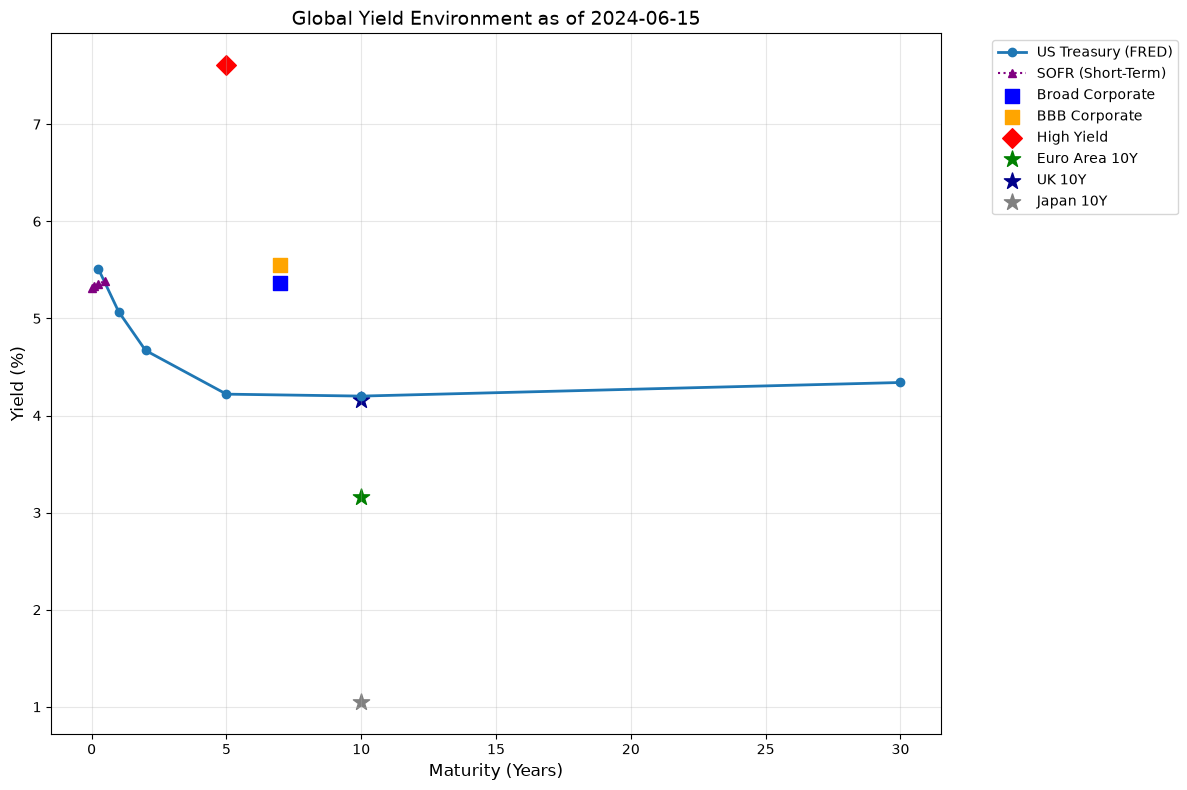

In [5]:
plt.figure(figsize=(12, 8))

# Treasury Curve
if "fred_data" in locals():
    plt.plot(
        list(fred_data.keys()),
        [v * 100 for v in fred_data.values()],
        marker="o",
        label="US Treasury (FRED)",
        linewidth=2,
    )

# SOFR Curve
if "sofr_data" in locals():
    plt.plot(
        list(sofr_data.keys()),
        [v * 100 for v in sofr_data.values()],
        marker="^",
        linestyle=":",
        label="SOFR (Short-Term)",
        color="purple",
    )

# Corporate Spreads (Plotted as single scatter points)
if "corp_data" in locals():
    plt.scatter(
        list(corp_data.keys()),
        [v * 100 for v in corp_data.values()],
        s=100,
        marker="s",
        color="blue",
        label="Broad Corporate",
    )
    plt.scatter(
        list(bbb_data.keys()),
        [v * 100 for v in bbb_data.values()],
        s=100,
        marker="s",
        color="orange",
        label="BBB Corporate",
    )
    plt.scatter(
        list(hy_data.keys()),
        [v * 100 for v in hy_data.values()],
        s=100,
        marker="D",
        color="red",
        label="High Yield",
    )

# Global Sovereigns (Plotted as single scatter points at year 10)
if "eur_data" in locals():
    plt.scatter(
        list(eur_data.keys()),
        [v * 100 for v in eur_data.values()],
        s=150,
        marker="*",
        color="green",
        label="Euro Area 10Y",
    )
    plt.scatter(
        list(gbr_data.keys()),
        [v * 100 for v in gbr_data.values()],
        s=150,
        marker="*",
        color="darkblue",
        label="UK 10Y",
    )
    plt.scatter(
        list(jpn_data.keys()),
        [v * 100 for v in jpn_data.values()],
        s=150,
        marker="*",
        color="grey",
        label="Japan 10Y",
    )

plt.title(f"Global Yield Environment as of {date}", fontsize=14)
plt.xlabel("Maturity (Years)", fontsize=12)
plt.ylabel("Yield (%)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Exploring the Breadth and Depth of FRED Fixed Income Data
Beyond standard government yield curves, FRED hosts an enormous variety of macroeconomic and fixed income data. Let's explore some key series:
1. **Macro & Policy Rates**: Federal Funds Rate (`FEDFUNDS`) and 30-Year Mortgage Rates (`MORTGAGE30US`).
2. **Inflation Markets**: 10-Year Breakeven Inflation (`T10YIE`) and Real Yields (`DFII10`).
3. **Credit Risk (Spreads)**: High Yield OAS (`BAMLH0A0HYM2`) vs Investment Grade OAS (`BAMLC0A0CM`).

*Note: We will fetch standard macro data over a 20-year deep history, and corporate spreads over a 3-year history (due to FRED's third-party licensing limits).*


/var/folders/zw/6c3qbkw16mv32wc4j28lg5_h0000gn/T/ipykernel_99059/3887065629.py:11: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  macro_data = web.DataReader(macro_tickers, "fred", start_date_macro, end_date)


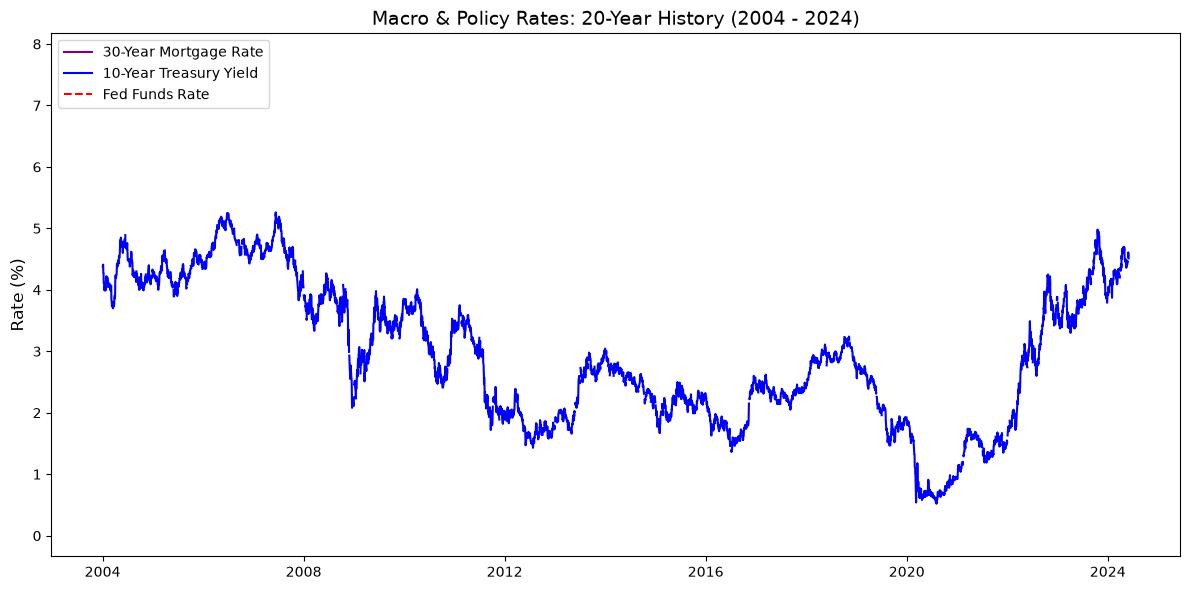

In [6]:
import pandas_datareader.data as web
import datetime
import matplotlib.pyplot as plt


start_date_macro = datetime.date(2004, 1, 1)
end_date = datetime.date(2024, 6, 1)

# Fetch Macro Rates (20 Years)
macro_tickers = ["FEDFUNDS", "MORTGAGE30US", "DGS10"]
macro_data = web.DataReader(macro_tickers, "fred", start_date_macro, end_date)

plt.figure(figsize=(12, 6))
plt.plot(
    macro_data.index,
    macro_data["MORTGAGE30US"],
    label="30-Year Mortgage Rate",
    color="purple",
)
plt.plot(
    macro_data.index, macro_data["DGS10"], label="10-Year Treasury Yield", color="blue"
)
plt.plot(
    macro_data.index,
    macro_data["FEDFUNDS"],
    label="Fed Funds Rate",
    color="red",
    linestyle="--",
)
plt.title("Macro & Policy Rates: 20-Year History (2004 - 2024)", fontsize=14)
plt.ylabel("Rate (%)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

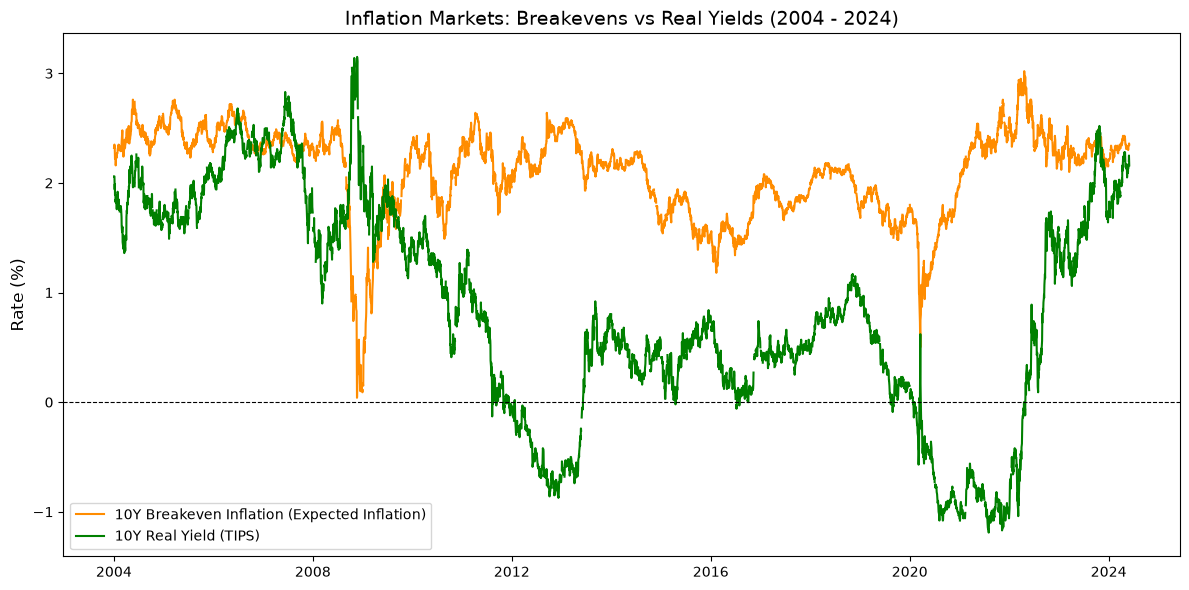

In [7]:
# Fetch Inflation Data (20 Years)
# T10YIE: 10-Year Breakeven Inflation Rate
# DFII10: 10-Year Treasury Inflation-Indexed Security (TIPS) - Real Yield
inflation_tickers = ["T10YIE", "DFII10"]
inflation_data = web.DataReader(inflation_tickers, "fred", start_date_macro, end_date)

plt.figure(figsize=(12, 6))
plt.plot(
    inflation_data.index,
    inflation_data["T10YIE"],
    label="10Y Breakeven Inflation (Expected Inflation)",
    color="darkorange",
)
plt.plot(
    inflation_data.index,
    inflation_data["DFII10"],
    label="10Y Real Yield (TIPS)",
    color="green",
)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Inflation Markets: Breakevens vs Real Yields (2004 - 2024)", fontsize=14)
plt.ylabel("Rate (%)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

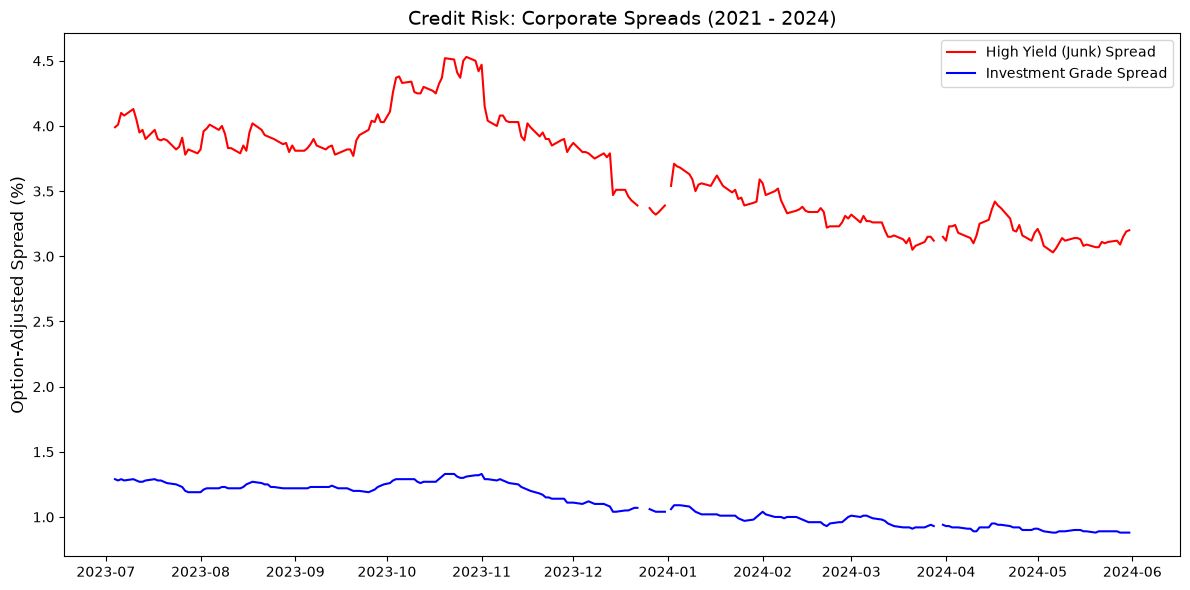

In [8]:
# Fetch Credit Spreads (3 Years due to ICE BofA limits on FRED)
# BAMLC0A0CM: US Corporate Index Option-Adjusted Spread
# BAMLH0A0HYM2: US High Yield Index Option-Adjusted Spread
start_date_credit = datetime.date(2021, 6, 1)

credit_tickers = ["BAMLC0A0CM", "BAMLH0A0HYM2"]
try:
    credit_data = web.DataReader(credit_tickers, "fred", start_date_credit, end_date)

    plt.figure(figsize=(12, 6))
    plt.plot(
        credit_data.index,
        credit_data["BAMLH0A0HYM2"],
        label="High Yield (Junk) Spread",
        color="red",
    )
    plt.plot(
        credit_data.index,
        credit_data["BAMLC0A0CM"],
        label="Investment Grade Spread",
        color="blue",
    )
    plt.title("Credit Risk: Corporate Spreads (2021 - 2024)", fontsize=14)
    plt.ylabel("Option-Adjusted Spread (%)", fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Could not fetch corporate spreads:", e)